In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [2]:
df_raw, y = load_iris(return_X_y=True, as_frame=True)
df_raw['y'] = y
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   y                  150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [3]:
df_raw.sample(10, random_state=2025)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),y
2,4.7,3.2,1.3,0.2,0
148,6.2,3.4,5.4,2.3,2
112,6.8,3.0,5.5,2.1,2
132,6.4,2.8,5.6,2.2,2
0,5.1,3.5,1.4,0.2,0
113,5.7,2.5,5.0,2.0,2
34,4.9,3.1,1.5,0.2,0
51,6.4,3.2,4.5,1.5,1
135,7.7,3.0,6.1,2.3,2
5,5.4,3.9,1.7,0.4,0


In [4]:
df_baking = df_raw.copy()
df_baking.columns = df_baking.columns.str.replace(' ','_').str.replace('(','').str.replace(')','')
df = df_baking.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sepal_length_cm  150 non-null    float64
 1   sepal_width_cm   150 non-null    float64
 2   petal_length_cm  150 non-null    float64
 3   petal_width_cm   150 non-null    float64
 4   y                150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [5]:
df_train, df_test = train_test_split(df, test_size=0.1, random_state=2025)
df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

X_train = df_train.drop(columns='y')
y_train = df_train['y']

X_test = df_test.drop(columns='y')
y_test = df_test['y']


df_train.shape, df_test.shape

((135, 5), (15, 5))

In [6]:
scaler = MinMaxScaler()
X_train_sc = scaler.fit_transform(X_train)
X_train_sc = pd.DataFrame(X_train, columns=X_train.columns)

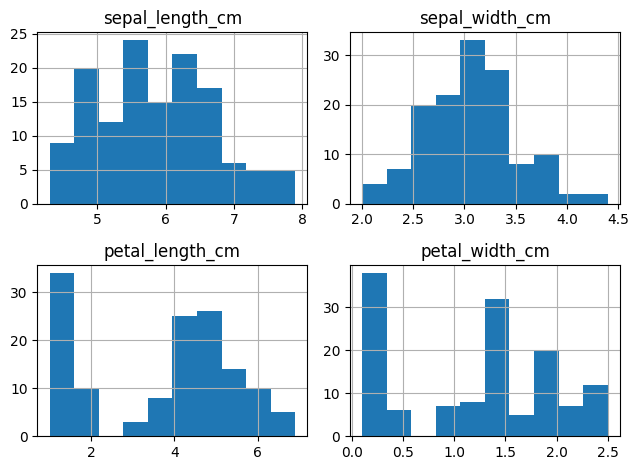

In [7]:
X_train_sc.hist()
plt.tight_layout()
plt.show()

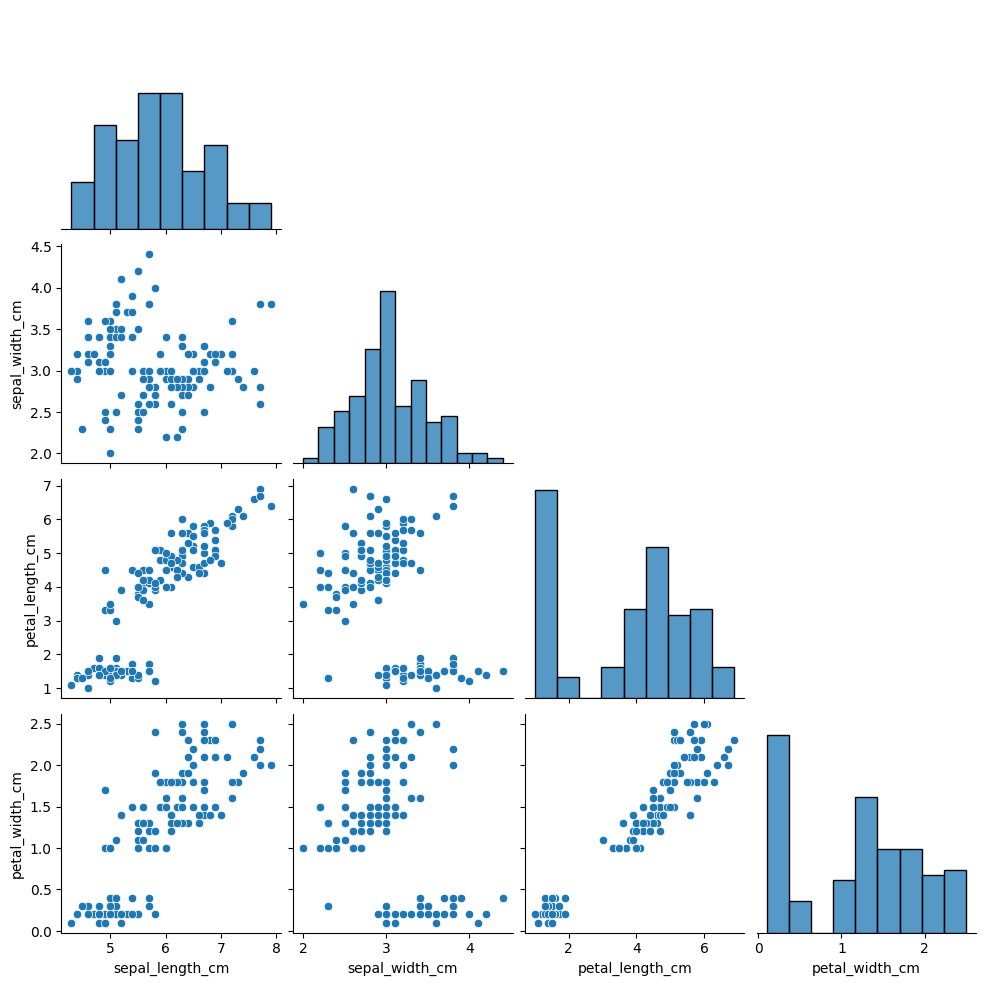

In [8]:
sns.pairplot(X_train_sc, corner=True)
plt.show()

In [9]:
clu_kmeans = KMeans(n_clusters=3)
clu_kmeans.fit(X_train_sc)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [10]:
labels = clu_kmeans.labels_
df_clustered = df_train

df_clustered['cluster'] = labels

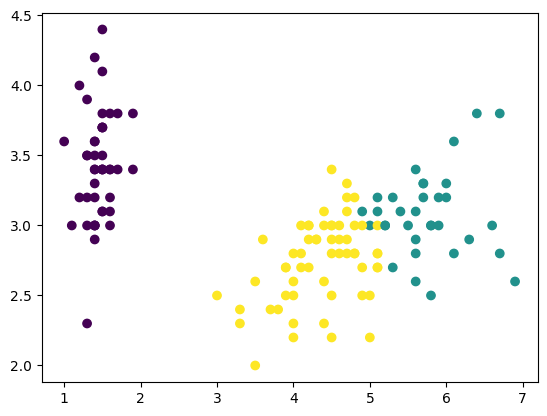

In [11]:
plt.scatter(x=df_clustered['petal_length_cm'], y=df_clustered['sepal_width_cm'], c=df_clustered['cluster'])
plt.show()

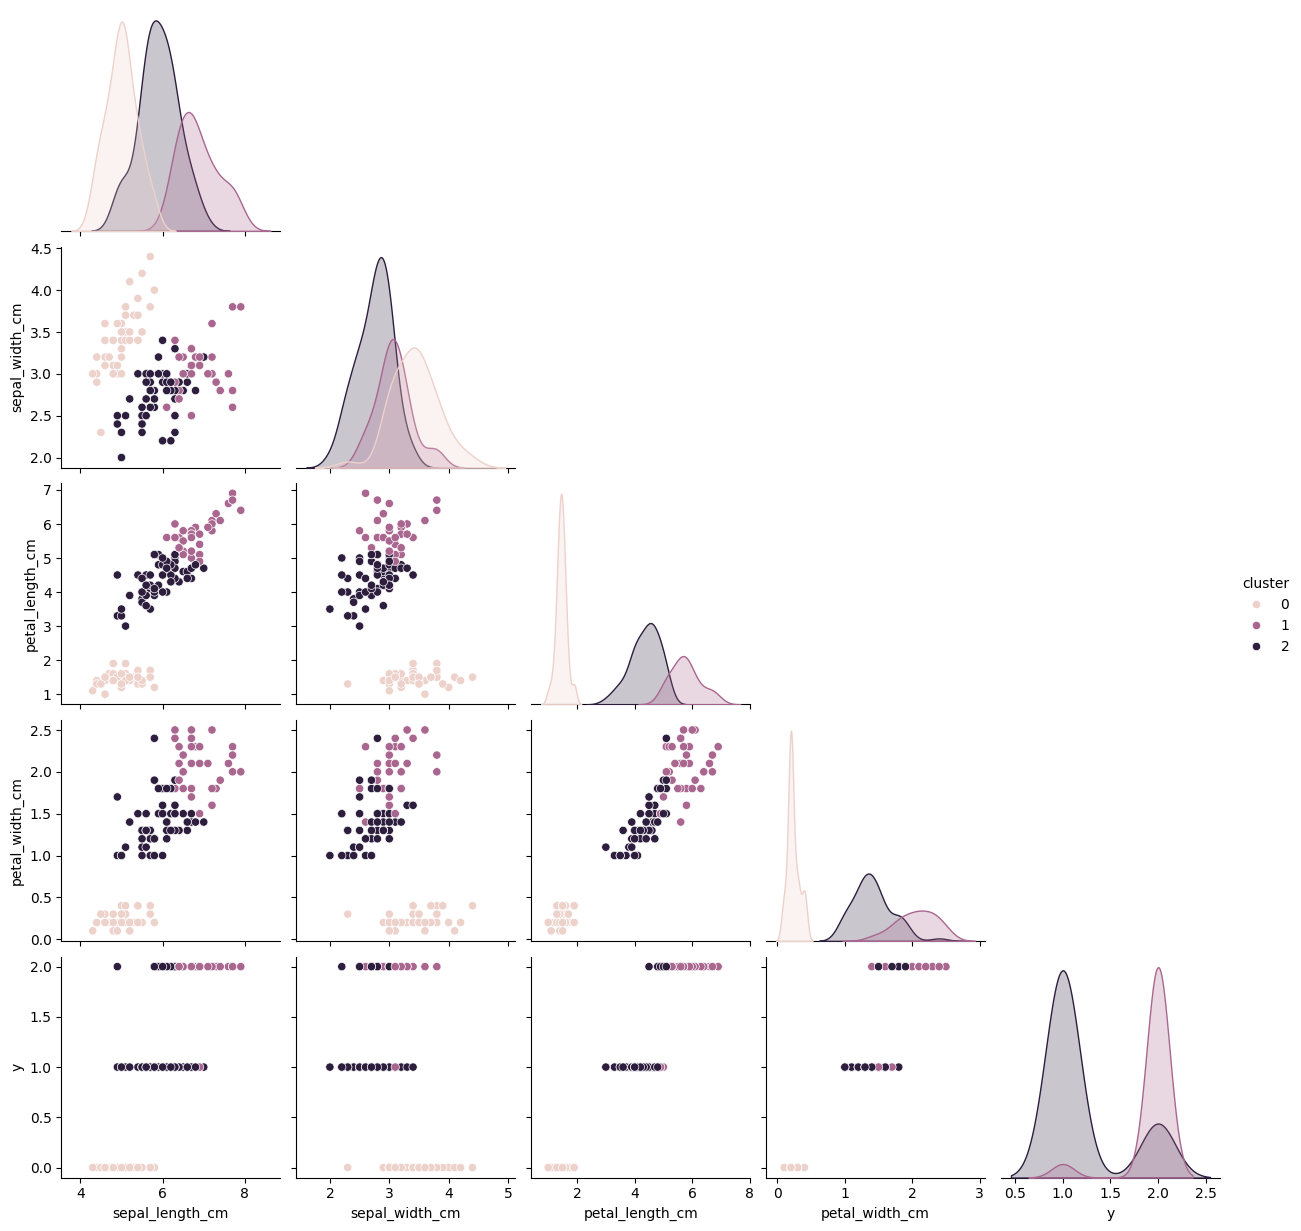

In [12]:
sns.pairplot(df_clustered, hue='cluster', corner=True)
plt.show()

In [13]:
sns.scatterplot(df_clustered, x='sepal_length_cm', y='sepal_width_cm', hue='cluster', style='true_cluster', palette='deep')
plt.show()

ValueError: Could not interpret value `true_cluster` for `style`. An entry with this name does not appear in `data`.

In [ ]:
inertia = []
K = range(1,10)

for k in K:
  k_means=KMeans(n_clusters=k)
  k_means.fit(X_train_sc)
  inertia.append(k_means.inertia_)

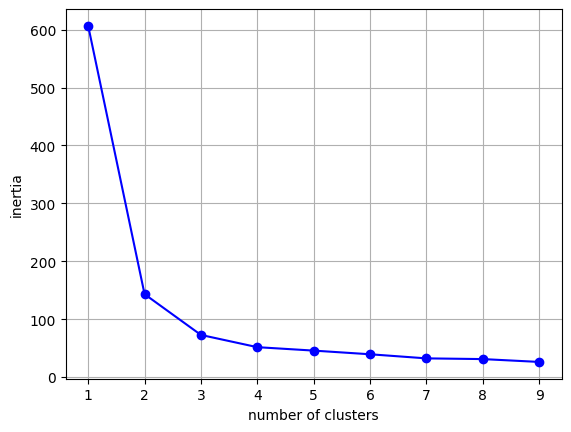

In [ ]:
plt.plot(K, inertia, 'bo-')
plt.xlabel('number of clusters')
plt.ylabel('inertia')
plt.grid(True)
plt.show()

In [ ]:
X = pd.read_csv('../data/wine_quality.csv')
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [ ]:
X.sample(10, random_state=2025)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
828,9.7,0.420,0.46,2.1,0.074,5.0,16.0,0.99649,3.27,0.74,12.300000,6,1172
850,8.6,0.420,0.39,1.8,0.068,6.0,12.0,0.99516,3.35,0.69,11.700000,8,1202
609,9.3,0.360,0.39,1.5,0.080,41.0,55.0,0.99652,3.47,0.73,10.900000,6,854
100,5.8,0.680,0.02,1.8,0.087,21.0,94.0,0.99440,3.54,0.52,10.000000,5,146
929,7.0,0.620,0.10,1.4,0.071,27.0,63.0,0.99600,3.28,0.61,9.200000,5,1309
91,5.6,0.500,0.09,2.3,0.049,17.0,99.0,0.99370,3.63,0.63,13.000000,5,131
93,8.4,0.745,0.11,1.9,0.090,16.0,63.0,0.99650,3.19,0.82,9.600000,5,135
50,8.3,0.675,0.26,2.1,0.084,11.0,43.0,0.99760,3.31,0.53,9.200000,4,73
307,8.0,0.670,0.30,2.0,0.060,38.0,62.0,0.99580,3.26,0.56,10.200000,6,436
1026,7.3,0.670,0.02,2.2,0.072,31.0,92.0,0.99566,3.32,0.68,11.066667,6,1439


In [ ]:
df_baking = X.copy()
df_baking.columns = df_baking.columns.str.replace(' ','_')
df_baking = df_baking.drop(columns=['quality', 'Id'])

df = df_baking.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         1143 non-null   float64
 1   volatile_acidity      1143 non-null   float64
 2   citric_acid           1143 non-null   float64
 3   residual_sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free_sulfur_dioxide   1143 non-null   float64
 6   total_sulfur_dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
dtypes: float64(11)
memory usage: 98.4 KB


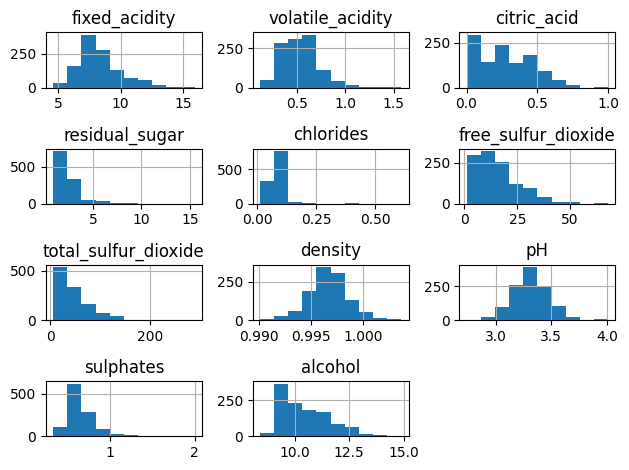

In [ ]:
df.hist()
plt.tight_layout()
plt.show()

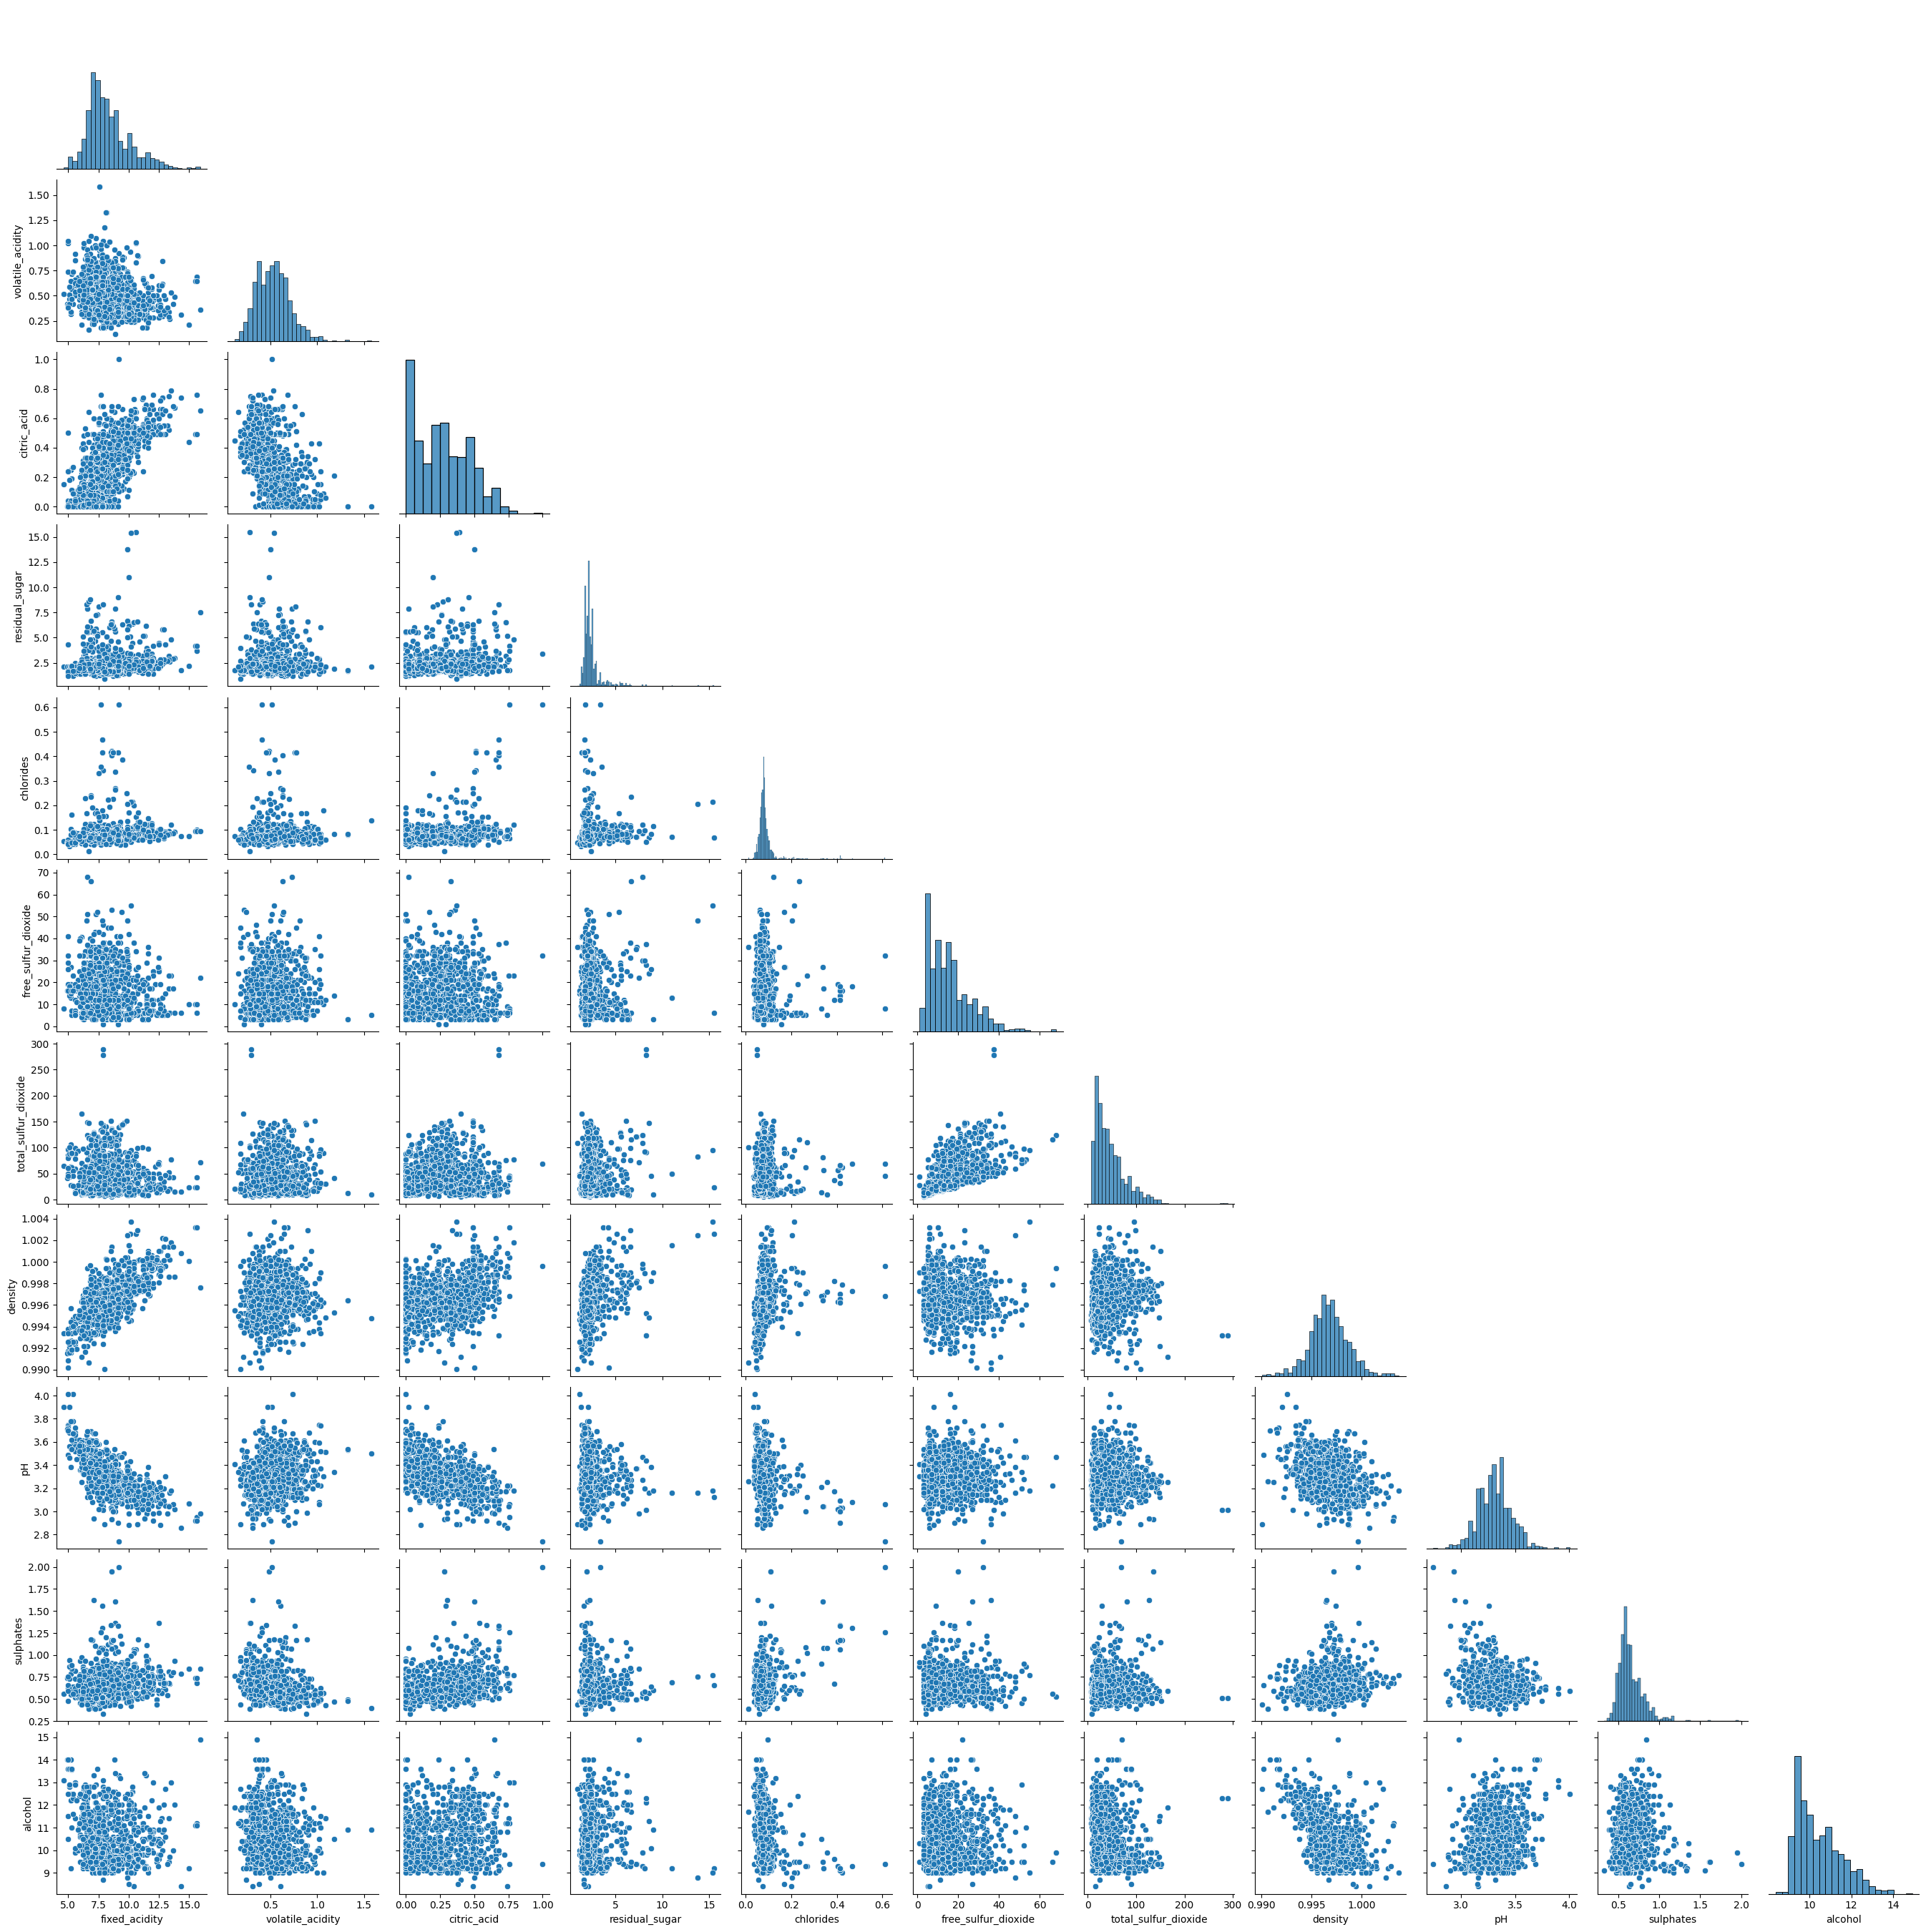

In [ ]:
sns.pairplot(df, corner=True)
plt.show()

In [ ]:
scaler = MinMaxScaler()
df_sc = scaler.fit_transform(df)
df_sc = pd.DataFrame(df_sc, columns=df.columns)

In [ ]:
inertia = []
K = range(1,10)

for k in K:
  k_means=KMeans(n_clusters=k)
  k_means.fit(df_sc)
  inertia.append(k_means.inertia_)

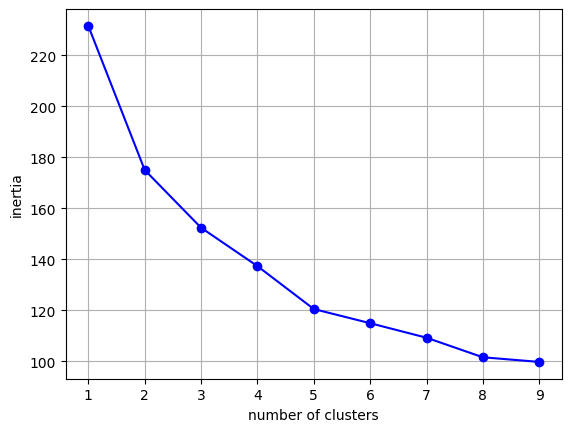

In [ ]:
plt.plot(K, inertia, 'bo-')
plt.xlabel('number of clusters')
plt.ylabel('inertia')
plt.grid(True)
plt.show()

In [ ]:
clu_kmeans = KMeans(n_clusters=2)
clu_kmeans.fit(df_sc)

KMeans(n_clusters=2)

In [ ]:
labels = clu_kmeans.labels_
df_clustered = df_sc

df_clustered['cluster'] = labels

In [ ]:
df_clustered

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,cluster
0,0.247788,0.397260,0.00,0.068493,0.106845,0.149254,0.098940,0.567548,0.606299,0.137725,0.153846,1
1,0.283186,0.520548,0.00,0.116438,0.143573,0.358209,0.215548,0.494126,0.362205,0.209581,0.215385,1
2,0.283186,0.438356,0.04,0.095890,0.133556,0.208955,0.169611,0.508811,0.409449,0.191617,0.215385,1
3,0.584071,0.109589,0.56,0.068493,0.105175,0.238806,0.190813,0.582232,0.330709,0.149701,0.215385,0
4,0.247788,0.397260,0.00,0.068493,0.106845,0.149254,0.098940,0.567548,0.606299,0.137725,0.153846,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1138,0.150442,0.267123,0.13,0.095890,0.106845,0.417910,0.120141,0.416300,0.535433,0.251497,0.400000,1
1139,0.194690,0.342466,0.08,0.068493,0.093489,0.402985,0.113074,0.472834,0.535433,0.293413,0.169231,1
1140,0.141593,0.328767,0.08,0.075342,0.130217,0.462687,0.134276,0.354626,0.559055,0.149701,0.323077,1
1141,0.115044,0.294521,0.10,0.089041,0.083472,0.567164,0.159011,0.370778,0.614173,0.257485,0.430769,1


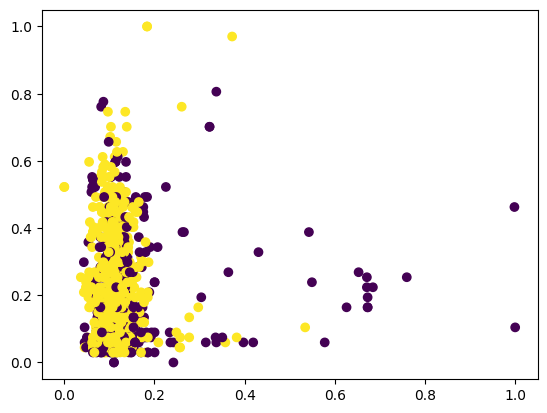

In [ ]:
plt.scatter(x=df_clustered['chlorides'], y=df_clustered['free_sulfur_dioxide'], c=df_clustered['cluster'])
plt.show()